In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cpu


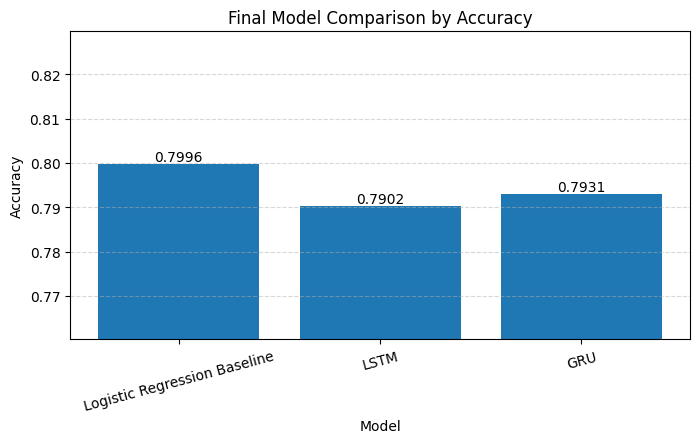

In [47]:
metric = "Accuracy"

plt.figure(figsize=(8, 4))

bars = plt.bar(
    final_comparison["Model"],
    final_comparison[metric]
)

plt.title("Final Model Comparison by Accuracy")
plt.xlabel("Model")
plt.ylabel(metric)

min_value = final_comparison[metric].min()
max_value = final_comparison[metric].max()

plt.ylim(
    max(0, min_value - 0.03),
    min(1, max_value + 0.03)
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

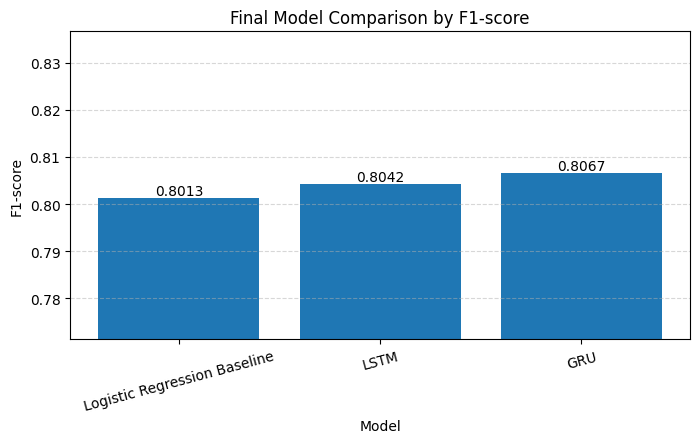

In [48]:
metric = "F1-score"

plt.figure(figsize=(8, 4))

bars = plt.bar(
    final_comparison["Model"],
    final_comparison[metric]
)

plt.title("Final Model Comparison by F1-score")
plt.xlabel("Model")
plt.ylabel(metric)

# Zoom Y-axis to make differences more visible
min_value = final_comparison[metric].min()
max_value = final_comparison[metric].max()

plt.ylim(
    max(0, min_value - 0.03),
    min(1, max_value + 0.03)
)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

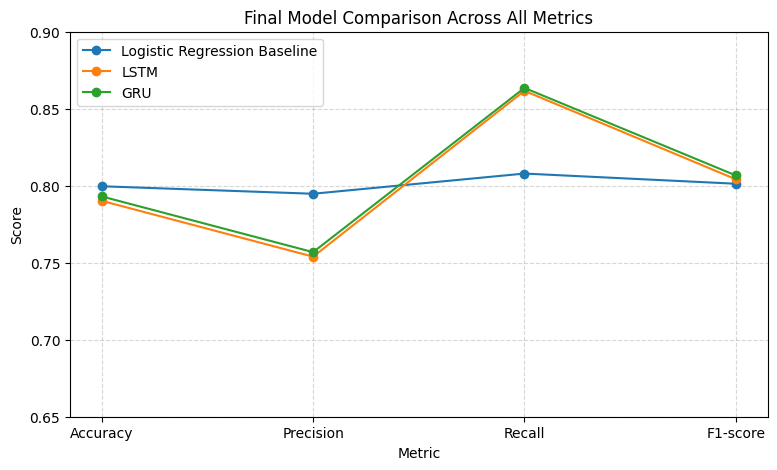

In [49]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(9, 5))

for _, row in final_comparison.iterrows():
    plt.plot(
        metrics,
        [row[m] for m in metrics],
        marker="o",
        label=row["Model"]
    )

plt.title("Final Model Comparison Across All Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0.65, 0.90)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

In [71]:
def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, lengths)
            probs = torch.sigmoid(logits)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)

    results = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "labels": all_labels,
        "predictions": all_preds,
        "probabilities": all_probs
    }

    return results

In [72]:
final_lstm_results = evaluate_model(
    lstm_model,
    test_loader,
    device,
    threshold=0.5
)

final_gru_results = evaluate_model(
    gru_model,
    test_loader,
    device,
    threshold=0.5
)

print("Final LSTM Evaluation")
print("---------------------")
print("Accuracy:", round(final_lstm_results["accuracy"], 4))
print("Precision:", round(final_lstm_results["precision"], 4))
print("Recall:", round(final_lstm_results["recall"], 4))
print("F1-score:", round(final_lstm_results["f1"], 4))

print("\nFinal GRU Evaluation")
print("--------------------")
print("Accuracy:", round(final_gru_results["accuracy"], 4))
print("Precision:", round(final_gru_results["precision"], 4))
print("Recall:", round(final_gru_results["recall"], 4))
print("F1-score:", round(final_gru_results["f1"], 4))

Final LSTM Evaluation
---------------------
Accuracy: 0.7982
Precision: 0.796
Recall: 0.8017
F1-score: 0.7989

Final GRU Evaluation
--------------------
Accuracy: 0.8026
Precision: 0.8008
Recall: 0.8057
F1-score: 0.8033


In [73]:
print("LSTM Classification Report:")
print(
    classification_report(
        final_lstm_results["labels"],
        final_lstm_results["predictions"],
        target_names=["negative", "positive"],
        zero_division=0
    )
)

print("\nGRU Classification Report:")
print(
    classification_report(
        final_gru_results["labels"],
        final_gru_results["predictions"],
        target_names=["negative", "positive"],
        zero_division=0
    )
)

LSTM Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.79      0.80     10000
    positive       0.80      0.80      0.80     10000

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000


GRU Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.80      0.80     10000
    positive       0.80      0.81      0.80     10000

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000



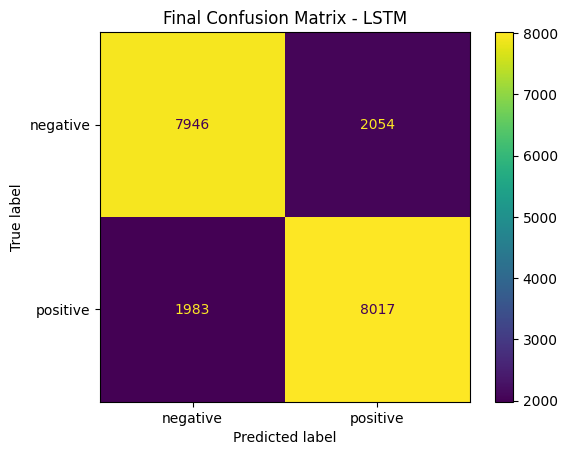

In [74]:
cm_lstm = confusion_matrix(
    final_lstm_results["labels"],
    final_lstm_results["predictions"]
)

disp_lstm = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["negative", "positive"]
)

disp_lstm.plot(values_format="d")
plt.title("Final Confusion Matrix - LSTM")
plt.show()

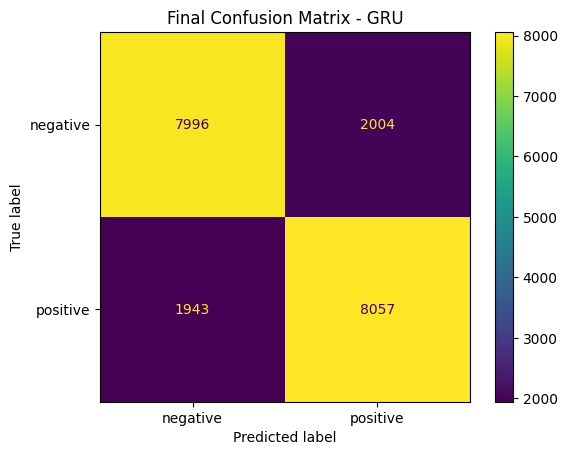

In [75]:
cm_gru = confusion_matrix(
    final_gru_results["labels"],
    final_gru_results["predictions"]
)

disp_gru = ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["negative", "positive"]
)

disp_gru.plot(values_format="d")
plt.title("Final Confusion Matrix - GRU")
plt.show()

## 9. Correct and Wrong Examples from Test Set

Instead of using manually created custom tweets, I use real examples from the test set.

This is more reliable because these tweets come from the same dataset structure as the training data.

In this section, I show:

- correct GRU predictions;
- wrong GRU predictions;
- examples where LSTM and GRU predict differently.

In [76]:
final_prediction_df = pd.DataFrame({
    "text": test_df["clean_text"].values,
    "true_label": final_gru_results["labels"],
    "lstm_prediction": final_lstm_results["predictions"],
    "gru_prediction": final_gru_results["predictions"],
    "lstm_positive_probability": final_lstm_results["probabilities"],
    "gru_positive_probability": final_gru_results["probabilities"]
})

final_prediction_df["true_sentiment"] = final_prediction_df["true_label"].map({
    0: "negative",
    1: "positive"
})

final_prediction_df["lstm_sentiment"] = final_prediction_df["lstm_prediction"].map({
    0: "negative",
    1: "positive"
})

final_prediction_df["gru_sentiment"] = final_prediction_df["gru_prediction"].map({
    0: "negative",
    1: "positive"
})

final_prediction_df["gru_correct"] = (
    final_prediction_df["true_label"] == final_prediction_df["gru_prediction"]
)

final_prediction_df["lstm_correct"] = (
    final_prediction_df["true_label"] == final_prediction_df["lstm_prediction"]
)

final_prediction_df.head()

,text,true_label,lstm_prediction,gru_prediction,lstm_positive_probability,gru_positive_probability,true_sentiment,lstm_sentiment,gru_sentiment,gru_correct,lstm_correct
0,user i know u don't luv me no more that's y u ...,0,0,0,0.312432,0.180714,negative,negative,negative,True,True
1,yesterday i was like yay vacations but no i ha...,0,0,0,0.101532,0.095392,negative,negative,negative,True,True
2,user good stuff,1,1,1,0.982886,0.976393,positive,positive,positive,True,True
3,enjoying a coffee with my bro at l'esspresso r...,1,1,1,0.996248,0.964153,positive,positive,positive,True,True
4,cooking noodles no lunch l,1,1,0,0.742191,0.311317,positive,positive,negative,False,True


In [78]:
different_predictions = final_prediction_df[
    final_prediction_df["lstm_prediction"] != final_prediction_df["gru_prediction"]
]

print("Number of different predictions between LSTM and GRU:", len(different_predictions))

different_predictions[
    [
        "text",
        "true_sentiment",
        "lstm_sentiment",
        "gru_sentiment",
        "lstm_positive_probability",
        "gru_positive_probability"
    ]
].head(10)

Number of different predictions between LSTM and GRU: 2312


,text,true_sentiment,lstm_sentiment,gru_sentiment,lstm_positive_probability,gru_positive_probability
4,cooking noodles no lunch l,positive,positive,negative,0.742191,0.311317
12,user oota love time differences was am when u ...,negative,negative,positive,0.279599,0.802590
13,user blackberry bolds and javelins now in stoc...,positive,negative,positive,0.178227,0.958925
21,user i'm sending u a lot of love no checks up ...,negative,negative,positive,0.322039,0.747915
40,watching raven wanting to give user a hug,negative,negative,positive,0.228226,0.542235
50,the trickeries of laser carwashing i don't hav...,negative,negative,positive,0.117449,0.717113
55,gucci mane doin that shit gotta love him just ...,positive,negative,positive,0.313065,0.532112
61,i starred on an user video check me and user o...,positive,positive,negative,0.530822,0.169109
65,already hungry for tonight's curry at china ex...,positive,negative,positive,0.466085,0.501059
70,i shouldnt be awake but omfg its today i cant ...,positive,positive,negative,0.560224,0.460589
